In [1]:
# Core Qiskit imports
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# IBM Runtim specific imports
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService

In [2]:
#
# First step is to map circuit
#

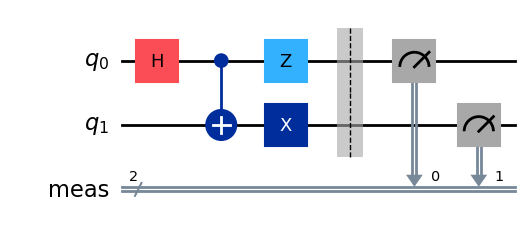

In [3]:
# Import Qiskit primitives
from qiskit import QuantumCircuit
import numpy as np

# make state
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)
qc.z(0)

# Measure state
qc.measure_all()

# Draw circuit
qc.draw("mpl")

In [4]:
# convert to qasm
from qiskit import qasm3

with open("test_circuit.qasm", "w") as fd:
    qasm3.dump(qc, fd)

In [5]:
#
# Next step is to optimize circuit to the specific backend being used
#

In [6]:
# # Pick the backend — same choice get_backend() makes in quantum_tools.py:212
# # backend = AerSimulator(method='statevector')
# # Alternatives:
# # backend = AerSimulator(method='statevector', device='GPU')
# from qiskit_ibm_runtime.fake_provider import FakeProviderForBackendV2
# backend = FakeProviderForBackendV2().backend('fake_manila')

# # Optimize to backend's gate set (equivalent to quantum_tools.py:432-438)
# pm = generate_preset_pass_manager(
#     backend=backend,
#     optimization_level=2,     # 0=none, 1=light, 2=default, 3=heaviest
#     seed_transpiler=42,
# )
# tqc = pm.run(qc)

# print(f'qubits: {tqc.num_qubits}  depth: {tqc.depth()}  '
#       f'gates: {sum(tqc.count_ops().values())}')
# tqc.draw("mpl")


Backend: fake_manila (fake)
  qubits: 2 -> 5
  depth:  4 -> 6
  gates:  7 -> 8


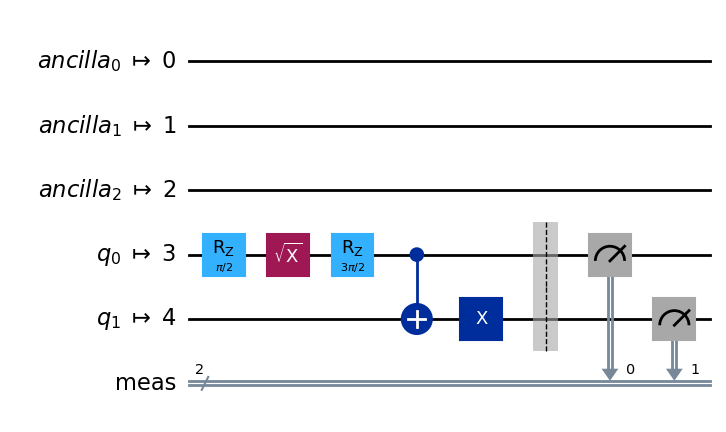

In [8]:
import sys; sys.path.append("../quantum-code-to-backend/src")
from qasm_transpile_qiskit import optimize_qasm

# # Local noiseless simulator (Aer)
# result = optimize_qasm("test_circuit.qasm",
#                        backend_type="ideal",
#                        backend_method="statevector",
#                        optimization_level=3)

# Fake IBM device (realistic noise, no credentials)
result = optimize_qasm("test_circuit.qasm",
                       backend_type="fake",
                       backend_method="fake_manila")

# # Real IBM hardware (least busy 127+ qubit device)
# result = optimize_qasm("test_circuit.qasm",
#                        backend_type="real-ibm",
#                        backend_method="least_busy",
#                        min_num_qubits=127)

result.circuit.draw("mpl")


In [ ]:
#
# Then run circuit and do whatever post-processing
#

{'01': 501, '10': 495, '11': 11, '00': 17}


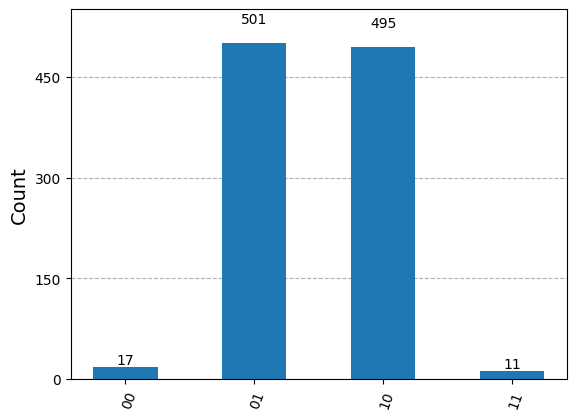

In [13]:
# Same exact pattern as run_circuit_ibm() in quantum_tools.py:484-508
shots = 1024
sampler = Sampler(result.backend)
job = sampler.run([result.circuit], shots=shots)
result = job.result()

counts = result[0].data.meas.get_counts()   # 'meas' is the register from measure_all()
print(counts)
plot_histogram(counts)
